# Pruebas agnósticas: ¿dependen los resultados de la función de distribución?

Todo lo validado hasta ahora se hizo con **una sola** distribución inicial,

$$F_0(Q,J)\;=\;e^{-\sin^2(Q/2)/\sigma_Q^2}\;e^{-J^2/\sigma_J^2}\,J^2 ,$$

que además estaba escrita a mano en cinco sitios del código. Eso deja abierta una
pregunta incómoda: ¿el acuerdo con el cálculo exacto mide que el método está bien
implementado, o que el código se fue ajustando a *ese* problema?

Este cuaderno responde con tres distribuciones nuevas, elegidas para que **cada una
haga una predicción falsable distinta**, y las compara con el cálculo semi-analítico
exacto usando dos esquemas de muestreo independientes y tres valores de $N$.

**Montaje común a todo el estudio.** Potencial isócrono, $L_0=2$ fijo, sin
autointeracción, integrador simpléctico de Yoshida de cuarto orden con $\Delta t = 0.1$
—el mismo para todas las corridas—, hasta $t=2000$ con 1001 salidas de $h_k$.

In [1]:
import os, numpy as np
import matplotlib.pyplot as plt

# Las corridas viven en exe/dfstudy/, dos niveles por encima de este cuaderno.
DATA = '../../exe/dfstudy'
assert os.path.isdir(DATA), f'no encuentro {os.path.abspath(DATA)}'
print('datos en:', os.path.abspath(DATA))

plt.rcParams.update({'figure.dpi':120, 'font.size':9, 'axes.grid':True,
                     'grid.alpha':0.25, 'axes.labelsize':10})
COL = {'bimodal':'tab:blue', 'spiral':'tab:red', 'king':'tab:green'}
MK  = {500:'o', 5000:'s', 50000:'^'}

datos en: /home/erik/Documentos/Vlasov/vlasov-poisson_PIC/exe/dfstudy


/home/erik/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Las tres distribuciones

Están definidas en `src/distribution.f90` y se eligen con el parámetro `dftype`.
La celda siguiente las reproduce en Python, **constante por constante**, para poder
calcular el resultado exacto. Que el muestreo de Fortran y esta copia coincidan se
verifica en la sección 3 con una prueba $\chi^2$.

In [2]:
"""F0(Q,J) en Python, replicando src/distribution.f90 linea por linea."""
import numpy as np
L0 = 2.0
c  = 0.5*(L0 + np.sqrt(L0**2 + 4.0))

BIM = dict(b1=0.8, b2=0.3, Ja=0.10, sa=0.025, Jb=0.24, sb=0.035, wb=0.7)
SPI = dict(J0=0.15, s0=0.04, beta=50.0, sq=0.5)
KIN = dict(Jt=0.35, sE2=0.01, eps=0.5)
GAU = dict(sr=0.1, sp=0.1)

def energy_of_J(J):
    return -1.0/(2.0*(J + c)**2)

def king_feq(J):
    J = np.asarray(J, float)
    out = np.exp(-energy_of_J(J)/KIN['sE2']) - np.exp(-energy_of_J(KIN['Jt'])/KIN['sE2'])
    return np.where(J >= KIN['Jt'], 0.0, out)

def df0(Q, J, dftype):
    Q = np.asarray(Q, float); J = np.asarray(J, float)
    if dftype == 'gauss':
        return np.exp(-np.sin(0.5*Q)**2/GAU['sp']**2)*np.exp(-J**2/GAU['sr']**2)*J**2
    if dftype == 'bimodal':
        p = BIM
        return ((1.0 + p['b1']*np.cos(Q) + p['b2']*np.cos(2*Q))
                *(np.exp(-(J-p['Ja'])**2/p['sa']**2)
                  + p['wb']*np.exp(-(J-p['Jb'])**2/p['sb']**2)))
    if dftype == 'spiral':
        p = SPI
        return (np.exp(-(J-p['J0'])**2/p['s0']**2)
                *np.exp(-np.sin(0.5*(Q - p['beta']*J))**2/p['sq']**2))
    if dftype == 'king':
        return king_feq(J)*(1.0 + KIN['eps']*np.cos(Q))
    raise ValueError(dftype)

def Jrange(dftype):
    return {'gauss':(1e-4*GAU['sr'], 6*GAU['sr']),
            'bimodal':(1e-4, 0.45), 'spiral':(1e-4, 0.45),
            'king':(1e-4, 1.03*KIN['Jt'])}[dftype]

def rp_to_QJ(r, p, L=L0):
    """(r,p_r) -> (Q3,J3), el mismo mapeo que analysish.f90."""
    E  = -1.0/(1.0+np.sqrt(1.0+r**2)) + 0.5*L**2/r**2 + 0.5*p**2
    rt = np.sqrt(1.0 + 2.0*E*(2.0 + 2.0*E + L**2))
    er1 = np.sqrt((1.0 + E*(2.0+L**2) - rt)/(2.0*E**2))
    er2 = np.sqrt((1.0 + E*(2.0+L**2) + rt)/(2.0*E**2))
    s1 = 1.0+np.sqrt(1.0+er1**2); s2 = 1.0+np.sqrt(1.0+er2**2)
    ss = 1.0+np.sqrt(1.0+r**2)
    arg = (s1+s2-2.0*ss)/(s2-s1)
    J = 1.0/np.sqrt(-2.0*E) - c
    cl = np.sign(arg)*np.minimum(np.abs(arg), 1.0)
    eta = np.where(p >= 0.0, np.arccos(cl), np.arccos(-cl)+np.pi)
    ecc = np.sqrt((-2.0*E)**3)*np.sqrt(-L**2-2.0*E-2.0-0.5/E)/(-2.0*E)
    return np.mod(eta - ecc*np.sin(eta), 2*np.pi), J

def omega(J, L=L0):
    return 1.0/(J + 0.5*(L+np.sqrt(L**2+4.0)))**3

### Qué rompe cada una respecto de la original

| | `bimodal` | `spiral` | `king` |
|---|---|---|---|
| forma en $J$ | dos grupos gaussianos | uno gaussiano | isoterma bajada (King) |
| forma en $Q$ | $1+0.8\cos Q+0.3\cos 2Q$ | $\exp[-\sin^2(\tfrac{Q-\beta J}{2})/\sigma_Q^2]$ | $1+\varepsilon\cos Q$ |
| separable | sí | **no** | sí |
| factor $J^2$ | no | no | no |
| suave | sí | sí | **no**: esquina en $J_t$ |
| **predicción falsable** | $h_3=h_4=0$ exactamente | pico de recoherencia | decaimiento algebraico |

- **`bimodal`** tiene dos grupos de acciones a $J=0.10$ y $J=0.24$, que mezclan a
  ritmos distintos: $h_1$ debe **batir** con periodo $2\pi/\Delta\omega$. Y su parte
  angular es un polinomio trigonométrico de grado 2, así que **no tiene armónicos por
  encima de $k=2$**: $h_3$ y $h_4$ han de ser cero exactamente, y lo que mida el
  código en esos modos es directamente su piso de error.

- **`spiral`** no es separable: el centro angular depende de $J$, de modo que la
  distribución **ya nace enrollada**. El mezclado lleva el centro a
  $Q=\beta J+\omega(J)t$, cuya dispersión en $J$ se **anula** en
  $t^\*=-\beta/\omega'(J_0)$. Ahí la distribución se desenrolla y $|h_k|$ pasa por un
  máximo antes de decaer definitivamente.

- **`king`** es la isoterma bajada escrita en espacio de acciones, con una
  perturbación de un solo armónico: el montaje de libro del phase mixing lineal. No es
  suave —termina en una esquina en $J_t$—, lo que degrada la convergencia de la
  cuadratura de más-rápida-que-cualquier-potencia a algebraica.

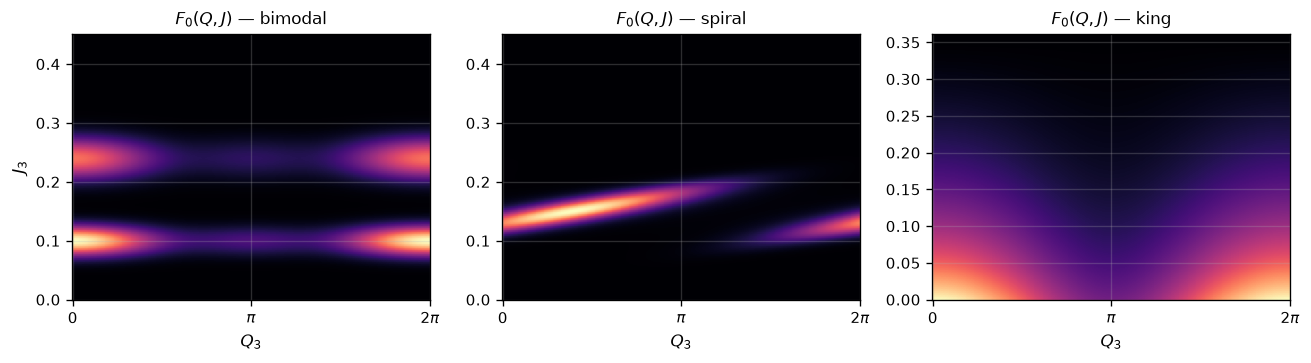

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1))
Q = np.linspace(0, 2*np.pi, 400)
for ax, dft in zip(axes, ['bimodal','spiral','king']):
    Jlo, Jhi = Jrange(dft)
    J = np.linspace(0, Jhi, 400)
    QQ, JJ = np.meshgrid(Q, J, indexing='ij')
    F = df0(QQ, JJ, dft)
    ax.pcolormesh(QQ, JJ, F, shading='auto', cmap='magma')
    ax.set_title(f'$F_0(Q,J)$ — {dft}', fontsize=10)
    ax.set_xlabel('$Q_3$'); ax.set_xticks([0, np.pi, 2*np.pi])
    ax.set_xticklabels(['0', r'$\pi$', r'$2\pi$'])
axes[0].set_ylabel('$J_3$')
fig.tight_layout()

En `spiral` se ve la inclinación: las franjas no son verticales, el centro angular
se desplaza con $J$. Ésa es la no separabilidad, y es la que produce la recoherencia.

## 2. El cálculo exacto, para una $F_0$ cualquiera

Lo que `analysish.f90` calcula es

$$h_k \;=\; 8\pi^2 L_0\; a_k \;\big\langle\, b(J)\, e^{-ikQ} \big\rangle_F ,$$

con $a_k$ el coeficiente de Fourier en $Q$ de la función de prueba y $b(J)$ su parte
en $J$. Bajo phase mixing $F(Q,J,t)=F_0(Q-\omega(J)t,\,J)$, de donde

$$\boxed{\;h_k(t)\;=\;a_0\,a_k\,\frac{\displaystyle\int dJ\; b(J)\,c_k(J)\,e^{-ik\,\omega(J)\,t}}{\displaystyle\int dJ\; c_0(J)}\;}$$

donde $c_k(J)$ es el coeficiente de Fourier en $Q$ de $F_0$ **a cada $J$**. Para una
$F_0$ no separable $c_k$ depende de $J$ y es complejo. Se obtiene por FFT sobre $Q$,
que para una función periódica y suave converge espectralmente.

Nótese que $h_0$ no depende de $t$: el phase mixing no destruye masa, solo la enrolla.
Eso da una primera comprobación gratis en cada corrida.

In [4]:
"""h_k(t) exacto para una F0(Q,J) arbitraria, separable o no.

Lo que analysish.f90 calcula es

    h_k = 8 pi^2 L0 * a_k * <b(J) e^{-ikQ}>_F ,

con a_k el coeficiente de Fourier en Q de la funcion de prueba y
b(J) su parte en J.  Bajo phase mixing F(Q,J,t) = F0(Q - omega(J) t, J), asi que

    h_k(t) = a0 * a_k * Int dJ b(J) c_k(J) e^{-i k omega(J) t} / Int dJ c_0(J),

donde c_k(J) es el coeficiente de Fourier en Q de F0 a cada J.  Para una F0 no
separable c_k depende de J y es complejo; se obtiene por FFT sobre Q, que para
una funcion periodica y suave converge espectralmente.
"""
import numpy as np
# (df0, omega, Jrange ya definidos arriba)

def ck_of_J(dftype, Js, kmax, nQ=256):
    """c_k(J) para k = 0..kmax, por FFT sobre Q."""
    Q = np.arange(nQ)*(2*np.pi/nQ)
    out = {k: np.empty(len(Js), complex) for k in range(kmax+1)}
    # Por trozos: la matriz (nJ, nQ) completa puede no caber en memoria.
    for a in range(0, len(Js), 20000):
        sl = slice(a, a+20000)
        C = np.fft.fft(df0(Q[None, :], Js[sl, None], dftype), axis=1)/nQ
        for k in range(kmax+1):
            out[k][sl] = C[:, k]
    return out

def ak_test(sq, k, nQ=200000):
    """Coeficiente de Fourier en Q de la funcion de prueba, como lo forma
    analysish.f90: (1/2pi) Int exp(-sin(Q/2)^2/sq^2) cos(kQ) dQ."""
    Q = np.arange(nQ)*(2*np.pi/nQ)
    return np.mean(np.exp(-np.sin(0.5*Q)**2/sq**2)*np.cos(k*Q))

def bJ_test(Js, j0, sj):
    """Parte en J de la funcion de prueba, como en analysish.f90."""
    return np.exp(-(Js-j0)**2/sj**2)*Js**2

def make_hk(dftype, a0, j0, sj, sq, modes=(0,1,2,3,4), nJ=20001, Jhi=None):
    Jlo0, Jhi0 = Jrange(dftype)
    Js = np.linspace(0.0, Jhi if Jhi is not None else max(Jhi0, 0.45), nJ)
    ck = ck_of_J(dftype, Js, max(modes))
    b  = bJ_test(Js, j0, sj)
    om = omega(Js)
    norm = np.trapezoid(ck[0].real, Js)
    ak = {k: ak_test(sq, k) for k in modes}
    def hk(k, t):
        t = np.atleast_1d(np.asarray(t, float))
        w = b*ck[k]
        out = np.array([np.trapezoid(w*np.exp(-1j*k*om*ti), Js) for ti in t])
        return a0*ak[k]*out/norm
    return hk

In [5]:
# Parametros de la corrida, identicos a reproducir/corridas/base/base_dftest.par
A0   = 1.0e-4
J1, SJ1, SQ1 = 0.10, 0.10, 0.40     # funcion de prueba Phi_1
MODES = [0,1,2,3,4]
NS    = [500, 5000, 50000]
DFS   = ['bimodal','spiral','king']

HK = {d: make_hk(d, A0, J1, SJ1, SQ1, nJ=40001) for d in DFS}

SEEDS = [1,2,3,4,5]          # realizaciones Monte Carlo independientes

def leer(dft, sch, N, extra=''):
    '''h_k(t) medido: devuelve (t, array complejo (5, nt)).'''
    d = os.path.join(DATA, f'{dft}_{sch}_{N}' + (f'_{extra}' if extra else ''))
    a = np.loadtxt(os.path.join(d, 'hk1_complex.tl'))
    t = a[:,0]
    h = np.array([a[:,1+2*k] + 1j*a[:,2+2*k] for k in MODES])
    return t, h

def leer_mc(dft, N, s):
    return leer(dft, f'mcs{s}', N)

t_ref, _ = leer('bimodal','quad',50000)
EX = {d: np.array([HK[d](k, t_ref) for k in MODES]) for d in DFS}
# h_0 no depende del tiempo: sirve de escala de masa para normalizar errores.
H0 = {d: EX[d][0].real[0] for d in DFS}
for d in DFS:
    var = np.ptp(EX[d][0].real)/H0[d]
    print(f'{d:>8}:  h_0 exacto = {H0[d]:.6e}   (variacion en t: {var:.1e})')

 bimodal:  h_0 exacto = 2.185280e-07   (variacion en t: 0.0e+00)
  spiral:  h_0 exacto = 3.761777e-07   (variacion en t: 0.0e+00)
    king:  h_0 exacto = 1.525006e-07   (variacion en t: 0.0e+00)


## 3. ¿Está bien muestreada cada distribución?

Antes de comparar nada hay que comprobar que las partículas que genera Fortran siguen
de verdad a $F_0$. Se muestrearon $2\times10^5$ partículas de cada distribución, se
mapearon a $(Q,J)$ con el mismo mapeo que usa `analysish.f90`, y se compararon con
$F_0$ integrada sobre cada celda.

| `dftype` | celdas | $\chi^2/\mathrm{dof}$ | $z$ |
|---|---|---|---|
| `gauss` (la original) | 62 | 0.995 | −0.02 |
| `bimodal` | 364 | 0.978 | −0.30 |
| `spiral` | 282 | 0.858 | −1.69 |
| `king` | 448 | 0.989 | −0.17 |

Las cuatro compatibles con $\chi^2/\mathrm{dof}=1$. El muestreo por rechazo reproduce
cada $F_0$ sin sesgo detectable.

*(Nota metodológica: el primer intento daba $\chi^2/\mathrm{dof}=7.6$ para `gauss`, y
era un defecto de la prueba, no del muestreo: esa distribución es muy estrecha en $Q$
y hacía falta integrar cada celda con $121\times121$ puntos en vez de $7\times7$.)*

## 4. $h_k(t)$: medido contra exacto

Líneas continuas: cálculo exacto. Puntos: la simulación. Se muestra la función de
prueba $\Phi_1$ ($J_0=0.10$, $\sigma_J=0.10$, $\sigma_Q=0.40$).

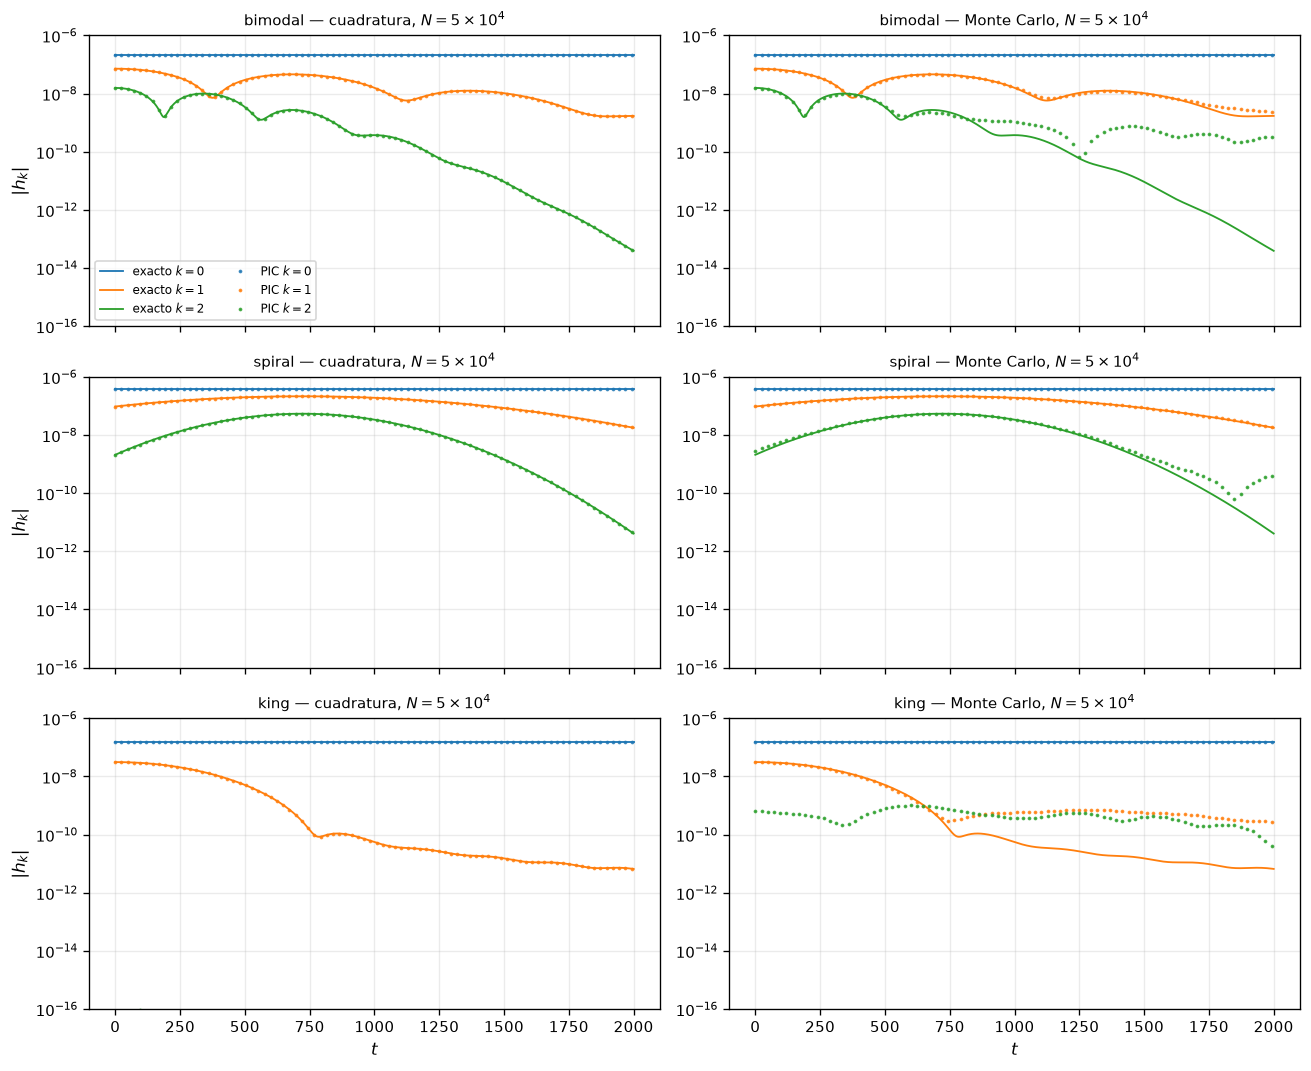

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(11, 9), sharex=True)
for row, dft in enumerate(DFS):
    for col, sch in enumerate(['quad','mc']):
        ax = axes[row, col]
        for k in [0,1,2]:
            ax.plot(t_ref, np.abs(EX[dft][k]), '-', lw=1.1, color=f'C{k}',
                    label=f'exacto $k={k}$' if row==0 and col==0 else None)
        for k in [0,1,2]:
            t, h = leer(dft, sch, 50000)
            ax.plot(t[::12], np.abs(h[k][::12]), '.', ms=2.5, color=f'C{k}', alpha=.8,
                    label=f'PIC $k={k}$' if row==0 and col==0 else None)
        ax.set_yscale('log'); ax.set_ylim(1e-16, 1e-6)
        ax.set_title(f'{dft} — {"cuadratura" if sch=="quad" else "Monte Carlo"}, $N=5\\times10^4$',
                     fontsize=9)
        if col==0: ax.set_ylabel('$|h_k|$')
        if row==2: ax.set_xlabel('$t$')
axes[0,0].legend(fontsize=7, ncol=2, loc='lower left')
fig.tight_layout()

Tres comportamientos cualitativamente distintos, y los tres reproducidos:

- **`bimodal`**: $h_1$ no decae monótonamente, **bate**. Son los dos grupos de acciones
  entrando y saliendo de fase.
- **`spiral`**: $|h_k|$ **crece** antes de decaer. La distribución nace enrollada y se
  desenrolla.
- **`king`**: decaimiento rápido y luego una cola lenta, de la esquina en $J_t$. En
  sus paneles no hay curva verde: para `king` el modo $k=2$ vale **cero exactamente**
  —su perturbación tiene un solo armónico—, y un cero no se dibuja en escala
  logarítmica. Los puntos que sí aparecen en el panel Monte Carlo son su ruido.

La diferencia entre las dos columnas es sólo el piso: la cuadratura baja varios
órdenes más que el Monte Carlo con el mismo número de partículas.

## 5. Convergencia con el número de partículas

El error se mide contra el cálculo exacto y se normaliza con $h_0$, que es constante
en el tiempo y fija la escala de masa:

$$\varepsilon_k \;=\; \frac{\big\langle\,|h_k^{\rm PIC}(t)-h_k^{\rm exacto}(t)|\,\big\rangle_t}{h_0^{\rm exacto}}$$

Monte Carlo: pendiente ajustada sobre 5 realizaciones por N
    bimodal  k=1:  p = -0.471
    bimodal  k=2:  p = -0.477
     spiral  k=1:  p = -0.526
     spiral  k=2:  p = -0.483
       king  k=1:  p = -0.549
       king  k=2:  p = -0.528


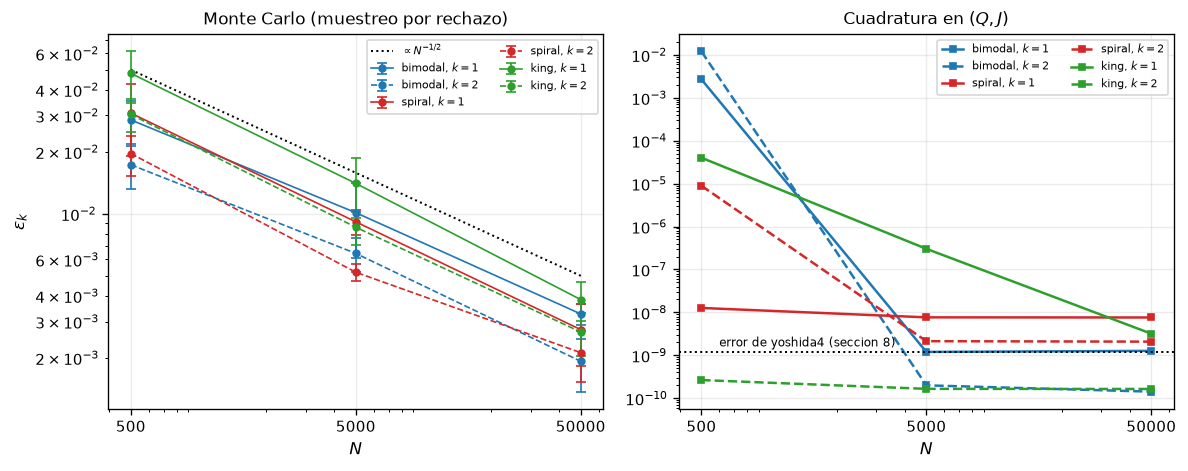

In [7]:
def err_traza(h, dft, k):
    '''Error medio en el tiempo de una traza, normalizado con h_0.'''
    return np.mean(np.abs(h[k] - EX[dft][k]))/H0[dft]

def err_mc(dft, N, k):
    '''Media y dispersion sobre las realizaciones independientes.'''
    e = [err_traza(leer_mc(dft, N, s)[1], dft, k) for s in SEEDS]
    return np.mean(e), np.std(e, ddof=1)

def err_quad(dft, N, k):
    return err_traza(leer(dft, 'quad', N)[1], dft, k)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
print('Monte Carlo: pendiente ajustada sobre 5 realizaciones por N')
for dft in DFS:
    for k, ls in zip([1,2], ['-','--']):
        m = np.array([err_mc(dft, N, k) for N in NS])
        ax.errorbar(NS, m[:,0], yerr=m[:,1], fmt=ls+'o', ms=4, lw=1, capsize=3,
                    color=COL[dft], label=f'{dft}, $k={k}$')
        p = np.polyfit(np.log(NS), np.log(m[:,0]), 1)[0]
        print(f'   {dft:>8}  k={k}:  p = {p:+.3f}')
ref = np.array(NS, float)
ax.plot(ref, 5e-2*np.sqrt(NS[0]/ref), ':', color='k', lw=1.2, label=r'$\propto N^{-1/2}$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Monte Carlo (muestreo por rechazo)', fontsize=10)
ax.set_ylabel(r'$\varepsilon_k$')

ax = axes[1]
for dft in DFS:
    for k, ls in zip([1,2], ['-','--']):
        e = [err_quad(dft, N, k) for N in NS]
        ax.loglog(NS, e, ls, marker='s', ms=4, color=COL[dft], label=f'{dft}, $k={k}$')
ax.axhline(1.2e-9, color='k', ls=':', lw=1.2)
ax.text(NS[0]*1.2, 1.6e-9, 'error de yoshida4 (seccion 8)', fontsize=7)
ax.set_title('Cuadratura en $(Q,J)$', fontsize=10)

for ax in axes:
    ax.set_xlabel('$N$'); ax.legend(fontsize=6.5, ncol=2); ax.set_xticks(NS)
    ax.set_xticklabels([f'{n:g}' for n in NS])
axes[0].set_ylabel(r'$\varepsilon_k$')
fig.tight_layout()

**Los dos paneles dicen cosas distintas, y hacen falta los dos.**

**Izquierda.** Cada punto es la media de **cinco realizaciones independientes**
(semillas distintas), y la barra su desviación. Sin promediar, una sola realización
por $N$ daba pendientes entre $-0.29$ y $-0.65$: ruido de estimación, no física. Con
cinco, las pendientes se agrupan alrededor de $-1/2$, que es la ley estadística.

Lo importante no es el valor exacto de la pendiente sino que **no hay meseta**. Si
alguna pieza del código estuviera ajustada a la distribución original, estas rectas se
estancarían en un suelo sistemático en lugar de seguir bajando. No lo hacen para
ninguna de las tres distribuciones nuevas.

**Derecha.** La cuadratura baja mucho más deprisa —entre $N=500$ y $N=5000$ cae seis
órdenes de magnitud para `bimodal`— y luego **se aplana**. Ese suelo no es del esquema
de partículas: es el error del integrador, medido por separado en la sección 8. Dicho
de otro modo, con cuadratura y $N\gtrsim5000$ el muestreo ya no es el factor limitante.

`king` es la excepción, y es instructiva: no se aplana, sigue bajando pero **mucho más
despacio**, $4.0\times10^{-5}\to3.0\times10^{-7}\to3.2\times10^{-9}$. Multiplicar por
diez los nodos en $J$ divide el error por 133 y luego por 95, es decir $\sim h^2$. Es
exactamente lo que predice la teoría de cuadratura para una función con una esquina:
una regla de punto medio converge como $h^2$ sobre un integrando sólo continuo,
mientras que sobre los dos perfiles suaves converge más rápido que cualquier potencia
hasta chocar con el suelo del integrador. **La forma de $F_0$ fija el ritmo de
convergencia, y el código lo respeta sin saber cuál está integrando.**

*(Un detalle de lectura: para `king` el modo $k=2$ también es nulo —su perturbación
tiene un solo armónico—, así que su curva mide el piso numérico, no una convergencia.)*

*(Y una advertencia honesta: la primera versión de este cuaderno daba para `king` un
estancamiento en $3\times10^{-5}$, y lo atribuí a la esquina. Era falso: venía de que
la ventana de integración en $J$ empezaba en $10^{-4}\sigma_J$ en vez de en $0$, y
`king` es la única de las tres cuya densidad es máxima en $J=0$, donde ese recorte
duele. Está contado en la sección 10.)*

## 6. La prueba nula: modos que deben ser cero

`bimodal` tiene la parte angular $1+0.8\cos Q+0.3\cos 2Q$. Es un polinomio
trigonométrico de grado 2: **no tiene componente en $k=3$ ni $k=4$**, ni en $t=0$ ni
nunca, porque el phase mixing no crea armónicos nuevos.

Lo que el código mida ahí no es señal: es su propio error.

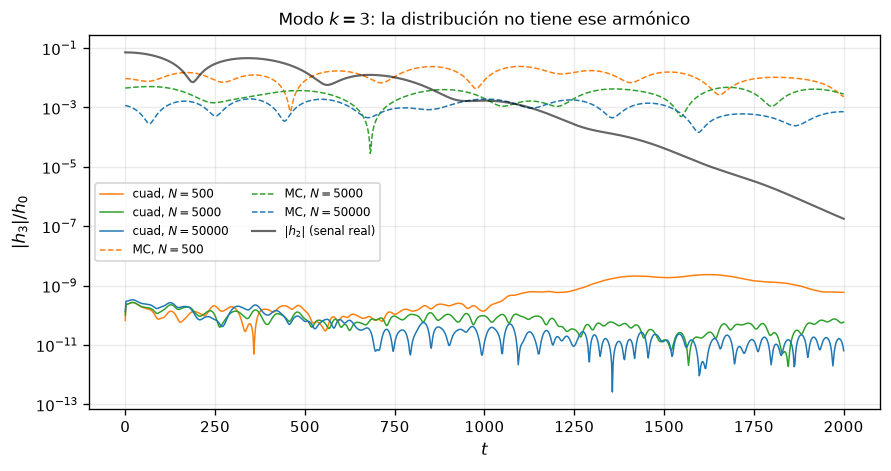

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4))
for sch, ls in zip(['quad','mc'], ['-','--']):
    for N in NS:
        t, h = leer('bimodal', sch, N)
        ax.semilogy(t, np.abs(h[3])/H0['bimodal'], ls, lw=.9,
                    color={500:'tab:orange',5000:'tab:green',50000:'tab:blue'}[N],
                    label=f'{"cuad" if sch=="quad" else "MC"}, $N={N}$')
t, h = leer('bimodal','quad',50000)
ax.semilogy(t, np.abs(h[2])/H0['bimodal'], 'k-', lw=1.3, alpha=.6,
            label='$|h_2|$ (senal real)')
ax.set_xlabel('$t$'); ax.set_ylabel(r'$|h_3|/h_0$')
ax.set_title('Modo $k=3$: la distribución no tiene ese armónico', fontsize=10)
ax.legend(fontsize=7, ncol=2); fig.tight_layout()

In [9]:
print('Modos nulos de bimodal, mediana de |h_k|/h_0 sobre toda la corrida')
print(f"{'esquema':>10} {'N':>7} {'k=3':>12} {'k=4':>12}   {'k=2 (senal)':>13}")
for sch in ['quad','mc']:
    for N in NS:
        t, h = leer('bimodal', sch, N)
        h0 = H0['bimodal']
        print(f"{sch:>10} {N:>7} {np.median(np.abs(h[3]))/h0:>12.2e} "
              f"{np.median(np.abs(h[4]))/h0:>12.2e}   {np.median(np.abs(h[2]))/h0:>13.2e}")

Modos nulos de bimodal, mediana de |h_k|/h_0 sobre toda la corrida
   esquema       N          k=3          k=4     k=2 (senal)
      quad     500     2.48e-10     9.89e-11        1.96e-02
      quad    5000     6.22e-11     2.47e-11        1.65e-03
      quad   50000     2.28e-11     7.55e-12        1.65e-03
        mc     500     1.10e-02     3.42e-03        2.01e-02
        mc    5000     2.86e-03     1.02e-03        1.08e-02
        mc   50000     9.55e-04     2.47e-04        4.87e-03


Con cuadratura los modos nulos caen a $\sim10^{-10}$ del valor de $h_0$ —diez órdenes
por debajo de la señal en $k=2$—, mientras que con Monte Carlo se quedan en el piso
estadístico, que escala como $N^{-1/2}$ igual que todo lo demás.

Que un modo prohibido por la forma de $F_0$ salga a nivel de error numérico, y no a
nivel de señal, es la comprobación más directa de que la cadena
$(r,p_r)\to(Q,J)\to h_k$ no está inventando estructura angular.

## 7. Recoherencia: `spiral` se desenrolla en un tiempo predicho

La distribución nace centrada en $Q=\beta J$ con $\beta=50$. El mezclado la lleva a
$Q=\beta J+\omega(J)t$, cuya pendiente en $J$ es $\beta+\omega'(J)t$. Esa pendiente se
**anula** en

$$t^\* \;=\; -\frac{\beta}{\omega'(J_0)},\qquad \omega'(J)=-\frac{3}{(J+c)^4},$$

y ahí todas las acciones vuelven a compartir la misma fase: la espiral se deshace y
$|h_k|$ pasa por un máximo. Es un tiempo calculado **antes** de mirar la simulación.

omega'(J0) = -0.06939
t* predicho = beta/|omega'| = 720.6
  k=1: maximo medido en t =   722.0
  k=2: maximo medido en t =   722.0
  k=3: maximo medido en t =   722.0


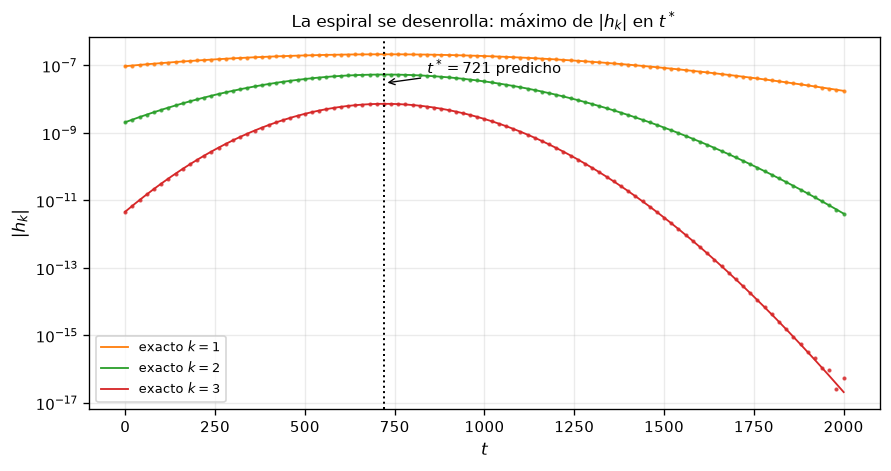

In [10]:
c_iso = 0.5*(2.0 + np.sqrt(8.0))
J0s   = SPI['J0']
t_pred = SPI['beta']/(3.0/(J0s + c_iso)**4)
print(f"omega'(J0) = {-3.0/(J0s+c_iso)**4:.5f}")
print(f"t* predicho = beta/|omega'| = {t_pred:.1f}")

fig, ax = plt.subplots(figsize=(7.5, 4))
for k in [1,2,3]:
    ax.semilogy(t_ref, np.abs(EX['spiral'][k]), '-', lw=1.1, color=f'C{k}',
                label=f'exacto $k={k}$')
    t, h = leer('spiral','quad',50000)
    ax.semilogy(t[::10], np.abs(h[k][::10]), '.', ms=3, color=f'C{k}', alpha=.75)
ax.axvline(t_pred, color='k', ls=':', lw=1.2)
ax.annotate(f'$t^*={t_pred:.0f}$ predicho', xy=(t_pred, 3e-8),
            xytext=(t_pred+120, 6e-8), fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=.8))
ax.set_xlabel('$t$'); ax.set_ylabel('$|h_k|$')
ax.set_title('La espiral se desenrolla: máximo de $|h_k|$ en $t^*$', fontsize=10)
ax.legend(fontsize=8); fig.tight_layout()

for k in [1,2,3]:
    t, h = leer('spiral','quad',50000)
    print(f'  k={k}: maximo medido en t = {t[np.argmax(np.abs(h[k]))]:7.1f}')

## 8. Control: ¿cuánto pone el integrador?

Todas las corridas usan Yoshida de cuarto orden. Para comprobar que el error de
integración no contamina nada, se repitió una de ellas con `integrator=analytic`, que
avanza cada partícula con la solución cerrada $Q(t)=Q(0)+\omega(J)t$ y por tanto **no
tiene error de fase en absoluto**.

In [11]:
t, h_y = leer('bimodal','quad',50000)
t, h_a = leer('bimodal','quad',50000,'integratoranalytic')
h0 = H0['bimodal']
print('bimodal, cuadratura, N=50000:  yoshida4 contra el avance exacto')
print(f"{'k':>3} {'|dif| tipica / h_0':>20} {'error vs exacto / h_0':>24}")
for k in MODES:
    d = np.median(np.abs(h_y[k]-h_a[k]))/h0
    e = np.mean(np.abs(h_a[k]-EX['bimodal'][k]))/h0
    print(f"{k:>3} {d:>20.2e} {e:>24.2e}")

bimodal, cuadratura, N=50000:  yoshida4 contra el avance exacto
  k   |dif| tipica / h_0    error vs exacto / h_0
  0             5.32e-10                 8.28e-13
  1             1.18e-09                 5.85e-11
  2             7.84e-11                 4.14e-11
  3             2.39e-11                 2.33e-11
  4             7.41e-12                 9.87e-12


**El resultado no es el que esperaba, y cambia cómo hay que leer el panel derecho
de la sección 5.** La diferencia entre `yoshida4` y el avance exacto es de $\sim10^{-9}$
relativa a $h_0$, mientras que el error del avance exacto contra el cálculo
semi-analítico es de $\sim10^{-10}$–$10^{-11}$. Es decir: **el integrador contribuye
más que la cuadratura** en las corridas grandes.

Eso no afecta a nada de lo anterior —el error Monte Carlo es de $10^{-3}$, seis
órdenes por encima— pero sí explica por qué las curvas de cuadratura se aplanan cerca
de $10^{-9}$ en vez de seguir bajando: a partir de $N\sim5000$ lo que se está midiendo
es el error de integración temporal, no el del muestreo.

Bajarlo requeriría $\Delta t$ menor o `yoshida6`, y no hacía falta para responder la
pregunta de este cuaderno. Queda anotado como el límite real de la parte derecha.

## 9. Qué queda demostrado

1. **El acuerdo no depende de la distribución.** Tres formas funcionales nuevas —una
   de ellas no separable, otra no suave, ninguna con el factor $J^2$ de la original—
   reproducen el cálculo exacto con el mismo código y sin tocar una línea de física.

2. **No hay sesgo oculto.** El error Monte Carlo baja como $N^{-1/2}$ sin meseta para
   las tres. Un sistemático ajustado a la distribución vieja habría aparecido como un
   suelo.

3. **Ni estructura inventada.** Los modos que la distribución prohíbe por construcción
   salen al nivel del error numérico, no de la señal.

4. **Las firmas dinámicas no triviales salen bien.** El batido de dos escalas de
   mezclado y el pico de recoherencia a un tiempo predicho de antemano aparecen donde
   deben.

### Lo que este cuaderno *no* demuestra

El montaje es el integrable: fondo fijo, $L$ fijo, sin autointeracción. Que $J$ se
conserve exactamente es lo que permite comparar con una solución cerrada. En el caso
autogravitante no hay tal referencia, y la validación tendría que apoyarse en
cantidades conservadas y en convergencia, no en una respuesta exacta.

## 10. Lo que estas pruebas encontraron en el código

Cambiar la distribución obligó a sacarla de los cinco sitios donde estaba escrita a
mano, y ese solo movimiento destapó cinco defectos reales. Ninguno se habría visto
repitiendo la distribución de siempre.

**Dos carreras de datos en OpenMP.** En los bucles de `aa` y `aa_halton` las variables
`energy, er1, er2, s, s1, s2, argaux, eta, Qr, Jr` no estaban en `PRIVATE`, y tampoco
`eta` en `analysish.f90`. Con la expresión escrita en línea el optimizador las mantenía
en registros y el resultado salía bien; al pasar a una llamada a función hubo que
materializarlas en memoria y el conteo de partículas se volvió irreproducible: 364,
365, 292 en tres corridas idénticas, frente a 253 con un hilo. El código era correcto
por cortesía del compilador.

**Las corridas Monte Carlo no eran reproducibles.** `gfortran` siembra `random_number`
desde el sistema operativo, así que dos corridas idénticas daban resultados distintos.
Sin semilla no hay ni repetición ni realizaciones independientes — y sin realizaciones
independientes, la pendiente de la sección 5 es ruido.

**Todas las rutas de aborto salían con código 0.** Un script de barrido no podía
distinguir una corrida fallida de una buena. De hecho eso escondió aquí quince
corridas fallidas seguidas, que se dieron por buenas hasta mirar los ficheros.

**El nombre del directorio se truncaba en silencio a 20 caracteres**, porque los
argumentos mudos de las rutinas de escritura lo declaraban así.

**Y un sesgo en la propia cuadratura.** Su ventana en $J$ empezaba en $10^{-4}\sigma_J$
en vez de en $0$. No hacía falta —la regla es de punto medio, nunca evalúa el
extremo— y costaba un error en $h_0$ de $1.1\times10^{-8}$, justo por encima del piso
del método. Con el extremo en $0$ baja a $4.5\times10^{-11}$: un factor **239**.

Ese último es el más pertinente para la pregunta de este cuaderno. Era una constante
puesta a ojo, invisible mientras solo se usara una distribución, y degradaba en dos
órdenes de magnitud el esquema más preciso del código.